<h1 style="color: #336699;"><b>MGC Spatial course</b></h1>

<h2 style="color: #336699;">Spatially-resolved transcriptomics data formats</h2>
<h3 style="color: #336699;">Day 1 - Practical 0</h3>

<h4>10th November 2025</h4>
<h4>Benedetta Manzato (LUMC)</h4>

<div style="border: 2px solid #336699; padding: 15px; border-radius: 8px;">
  <span style="color: #336699; font-size: 24px; font-weight: bold;">Agenda:</span>
  <ol style="margin-top: 10px; padding-left: 25px; font-size: 17px; color: #333333;">
    <li>Introduction to AnnData</li>
    <li>Introduction to SpatialData</li>
    <li>Accessing images</li>
  </ol>
</div>

In [ ]:
import warnings
warnings.filterwarnings("ignore")

# Importing necessary libraries for spatial data analysis and visualization
import os, re
import scanpy as sc
import scanpy.external as sce
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import random
import numpy as np
import anndata as ad

# Display the version of important packages for reproducibility
sc.logging.print_header()

# Set the default aesthetics for Scanpy plots
sc.set_figure_params(facecolor='white', figsize=(8, 8))  # White background, figure size 8x8
sc.settings.verbosity = 0  # Set verbosity to show only errors (0) # errors (0), warnings (1), info (2), hints (3)

## AnnData format

<font size="3"> Expression matrices are stored in the [anndata h5ad format](https://anndata.readthedocs.io/en/latest/) and need to be downloaded to a local file system for usage.

<font size="3">**Key Components of an AnnData Object:**

<font size="3">- **`.X`**: The main data matrix (usually cells by genes), where the rows are cells and the columns are genes. It typically stores raw or normalized gene expression data.

<font size="3">- **`.obs`**: Observations (metadata about the cells), such as cell type, experimental conditions, or quality control metrics.

<font size="3">- **`.var`**: Variables (metadata about the genes), such as gene names or other annotations.

<font size="3">- **`.obsm`**: Multi-dimensional annotations of cells, such as dimensionality reduction results (e.g., PCA, UMAP coordinates).

<font size="3">- **`.uns`**: Unstructured annotations, typically storing experimental metadata or plot settings.

<font size="3">- **`.layers`**: Stores multiple versions of the data matrix (e.g., raw counts, normalized data, etc.).

    
<figure>
  <img 
    src="https://raw.githubusercontent.com/scverse/anndata/main/docs/_static/img/anndata_schema.svg"
    alt="AnnData format structure"
    width="500">
  <figcaption>
    From 
    <a href="https://raw.githubusercontent.com/scverse/anndata/main/docs/_static/img/anndata_schema.svg" 
       target="_blank" rel="noopener noreferrer">
      Virshup et al. (2024), JOSS
    </a>
  </figcaption>
</figure>

<div style="border: 2px solid #c1121f; padding: 15px; border-radius: 8px;">
  <ul style="margin-top: 10px; padding-left: 25px; font-size: 17px; color: #c1121f; list-style-type: none; font-weight: bold;">
    <li>Question: where do you expect spatial coordinates to be stored?</li>
  </ul>
</div>


### Dataset: MERFISH Spatial Transcriptomics of Adult Mouse Brain (Zhuang‑ABCA‑1)

<p style="font-size:1.1em; line-height:1.6;">
  This dataset presents a spatially resolved cell atlas of the adult mouse brain using multiplexed error‑robust fluorescence in situ hybridization (<strong>MERFISH</strong>). 
  A panel of 1,122 genes was imaged across ~9 million cells, integrated with Allen Institute scRNA‑seq data to define over 5,000 transcriptionally distinct clusters 
  belonging to ~300 major cell types. The atlas was spatially registered to the Allen Mouse Brain Common Coordinate Framework (<strong>CCFv3</strong>), enabling 
  systematic quantification of cell types and spatial organization across brain regions.
</p>

<p style="font-size:1.1em; line-height:1.6;">
  <strong>Collections:</strong> Four mouse specimens (two coronal, two sagittal):
</p>

<ul style="font-size:1.1em; line-height:1.5;">
  <li><strong>Zhuang‑ABCA‑1:</strong> 4.2 M cells, 147 coronal sections, 1,122‑gene panel; 2.8 M filtered.</li>
  <li><strong>Zhuang‑ABCA‑2:</strong> 1.9 M cells, 66 coronal sections; 1.2 M filtered.</li>
  <li><strong>Zhuang‑ABCA‑3:</strong> 2.1 M cells, 23 sagittal sections; 1.6 M filtered.</li>
  <li><strong>Zhuang‑ABCA‑4:</strong> 0.22 M cells, 3 sagittal sections; 0.16 M filtered.</li>
</ul>

<p style="font-size:1.1em; line-height:1.6;">
  We will focus on the <strong>Brain Coronal 1 (Zhuang‑ABCA‑1)</strong> dataset. Filtered data (~5.8 M cells) and spatial coordinates (5.4 M cells registered to the 3D Allen‑CCF) are available from the AWS bucket.
</p>

<p style="font-size:1.1em; line-height:1.6;">
  <strong style="color: #c1121f;">
    We previously selected the section with the most cells (section 80) for our analysis.
  </strong>
  For detailed instructions on how to download data objects using <code>AbcProjectCache</code> and about the preprocessing, see the notebook at:
  <a href="https://github.com/BrainOmicsCourse/BrainOmics2024/blob/main/3_Day3/spatial_day3.ipynb" target="_blank" rel="noopener noreferrer">
    BrainOmics2024 Day 3 Spatial Notebook
  </a>
</p>

For more details: [Molecularly defined and spatially resolved cell atlas of the whole mouse brain (Zhang et al. 2023)](https://www.nature.com/articles/s41586-023-06808-9)

From https://github.com/AllenInstitute/abc_atlas_access/blob/main/notebooks/zhuang_merfish_tutorial.ipynb

Data Availablity : https://knowledge.brain-map.org/data/5C0201JSVE04WY6DMVC/collections </font>

### Read data

In [ ]:
adata = ad.read_h5ad('data/adata_section80.h5ad')
adata

<font size="3">Access cell metadata with <code>.obs</code>

In [ ]:
adata.obs

<font size="3">Access feature metadata with <code>.var</code>

In [ ]:
adata.var

In [ ]:
print(f"Total number of cells/spots in this section: {adata.shape[0]}")
print(f"Size of the gene panel: {adata.shape[1]}")

<font size="3">In <code>.obs</code> we see that a class, subclass, supertype and cluster annotation is available. 

    
<font size="3">We can plot it spatially in a scatterplot (using <code>scanpy.pl.scatter</code> or <code>scanpy.pl.spatial</code>).

<font size="3"> <code>Scanpy</code> (and other spatial analysis tools) require <code>adata.obsm['X_spatial']</code> or <code>adata.obsm['spatial']</code>. It is already present in our object; if it’s not, you can add it with:

```python
# add X_spatial
import numpy as np

adata_section.obsm['X_spatial'] = np.array(adata_section.obs[['x', 'y']])
adata_section.obsm['X_spatial']


In [ ]:
annotations = ['class', 'subclass', 'supertype', 'cluster']

for ann in annotations:
    fig, ax = plt.subplots(figsize=(8, 8))
    sc.pl.scatter(
        adata,
        x='x',
        y='y',
        color=ann,
        ax=ax,
        size=10,
        show=False,
        title=ann.capitalize()
    )
    ax.invert_yaxis()
    ax.axis('equal')
    ax.set_xlabel('X Coordinate')
    ax.set_ylabel('Y Coordinate')
    ax.tick_params(axis='both', which='both',
                   bottom=False, left=False,
                   labelbottom=False, labelleft=False)
    ax.grid(False)
    plt.tight_layout()
    plt.show()


<font size="3">Alternatively we can plot a simple scatterplot with <code>seaborn/matplotlib</code> (using the color scheme available in <code>adata.obs[{cluster}_color]</code>.

In [ ]:
# Create the color mapping dictionaries

class_palette = dict(zip(adata.obs['class'].unique(), adata.obs['class_color'].unique()))
subclass_palette = dict(zip(adata.obs['subclass'].unique(), adata.obs['subclass_color'].unique()))
supertype_palette = dict(zip(adata.obs['supertype'].unique(), adata.obs['supertype_color'].unique()))
cluster_palette = dict(zip(adata.obs['cluster'].unique(), adata.obs['cluster_color'].unique()))

# Create the subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 15))
fig.suptitle('Scatter Plots of Different Categories', fontsize=16)

# Plot 'class' using class_color
sns.scatterplot(ax=axes[0, 0], x='x', y=-adata.obs['y'], hue='class', palette=class_palette, data=adata.obs, s=8, legend=False)
axes[0, 0].set_title('Class')
axes[0, 0].set_xlabel('X Coordinate')
axes[0, 0].set_ylabel('Y Coordinate')
axes[0, 0].tick_params(axis='both', which='both', bottom=False, left=False, labelbottom=False, labelleft=False)
axes[0, 0].grid(False)  # Remove grid

# Plot 'subclass' using subclass_color
sns.scatterplot(ax=axes[0, 1], x='x', y=-adata.obs['y'], hue='subclass', palette=subclass_palette, data=adata.obs, s=8, legend=False)
axes[0, 1].set_title('Subclass')
axes[0, 1].set_xlabel('X Coordinate')
axes[0, 1].set_ylabel('Y Coordinate')
axes[0, 1].tick_params(axis='both', which='both', bottom=False, left=False, labelbottom=False, labelleft=False)
axes[0, 1].grid(False)  # Remove grid

# Plot 'supertype' using supertype_color
sns.scatterplot(ax=axes[1, 0], x='x', y=-adata.obs['y'], hue='supertype', palette=supertype_palette, data=adata.obs, s=8, legend=False)
axes[1, 0].set_title('Supertype')
axes[1, 0].set_xlabel('X Coordinate')
axes[1, 0].set_ylabel('Y Coordinate')
axes[1, 0].tick_params(axis='both', which='both', bottom=False, left=False, labelbottom=False, labelleft=False)
axes[1, 0].grid(False)  # Remove grid

# Plot 'cluster' using cluster_color
sns.scatterplot(ax=axes[1, 1], x='x', y=-adata.obs['y'], hue='cluster', palette=cluster_palette, data=adata.obs, s=8, legend=False)
axes[1, 1].set_title('Cluster')
axes[1, 1].set_xlabel('X Coordinate')
axes[1, 1].set_ylabel('Y Coordinate')
axes[1, 1].tick_params(axis='both', which='both', bottom=False, left=False, labelbottom=False, labelleft=False)
axes[1, 1].grid(False)  # Remove grid

plt.tight_layout(rect=[0, 0, 1, 0.96])  
plt.show()


<font size="3"> You can also plot the gene expression of genes of interest:

In [ ]:
genes_toplot = ['Zic1','Penk','Gfap']

sc.pl.spatial(adata, color=genes_toplot,spot_size=0.04)

### Building blocks of `anndata.AnnData` class

### Metadata

<font size="3">`.obs` and `.var`: These are stored as `pandas.DataFrame` objects to handle metadata efficiently.

<font size="3">Use cases include filtering, subsetting, and quick visualizations.
    
    #### `pandas.DataFrame`
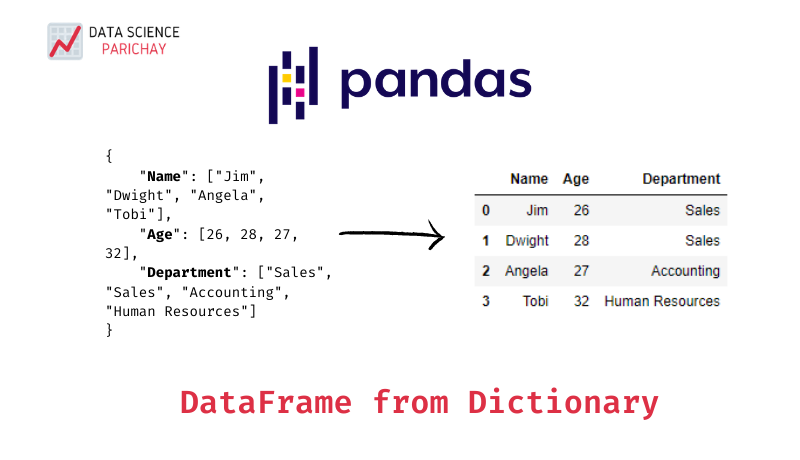

<font size="3">Let's filter the AnnData object to keep only cells labelled as <code>31 OPC-Oligo</code> or <code>16 HY MM Glut</code>

In [ ]:
adata_filtered_obs = adata[adata.obs['class'].isin(['31 OPC-Oligo','16 HY MM Glut'])]
adata_filtered_obs

<div style="border: 2px solid #c1121f; padding: 15px; border-radius: 8px;">
  <ul style="margin-top: 10px; padding-left: 25px; font-size: 17px; color: #c1121f; list-style-type: none; font-weight: bold;">
    <li>Exercise: Filter the AnnData object to keep only cells labelled as <code>'01 IT-ET Glut'</code></li>
  </ul>
</div>

In [ ]:
adata_filtered_obs = adata[adata.obs['class'] == '01 IT-ET Glut']
adata_filtered_obs.obs

<div style="border: 2px solid #c1121f; padding: 15px; border-radius: 8px;">
  <ul style="margin-top: 10px; padding-left: 25px; font-size: 17px; color: #c1121f; list-style-type: none; font-weight: bold;">
    <li>Exercise: Filter the AnnData object to keep only <code>Lmo1, Gata3, Aqp6</code> genes </li>
      Reminder: we can think of .obs as the rows of a pandas dataframe and .var as the columns 
  </ul>
</div>

In [ ]:
adata_filtered_var = adata[......]
adata_filtered_var.var

### `scipy.sparse` Matrices
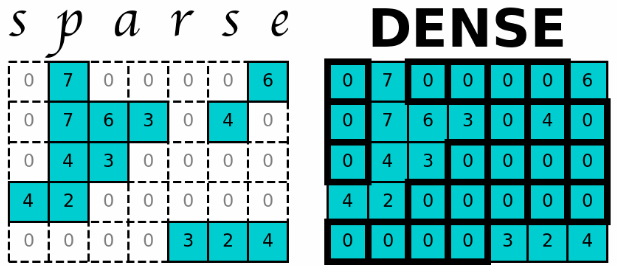

<div style="font-size: 1.1em; line-height: 1.5;">
  <p>
    Large datasets (e.g., single-cell or spatial datasets) are often sparse, meaning most of the matrix entries are zero. 
    To save memory and computation time, these matrices are stored in sparse formats.
  </p>

  <p><strong>Common Formats:</strong></p>
  
  <p><code>scipy.sparse</code> matrices:</p>
  <ul>
    <li><code>csr_matrix</code> (Compressed Sparse Row): Efficient for row slicing.</li>
    <li><code>csc_matrix</code> (Compressed Sparse Column): Efficient for column slicing.</li>
    <li><code>coo_matrix</code> (Coordinate): Useful for constructing sparse matrices.</li>
  </ul>
</div>


<div style="border: 2px solid #c1121f; padding: 15px; border-radius: 8px;">
  <ul style="margin-top: 10px; padding-left: 25px; font-size: 17px; color: #c1121f; list-style-type: none; font-weight: bold;">
    <li>Is the AnnData object currently in a dense or sparse format?</li>
  </ul>
</div>

In [ ]:
### check adata count matrix 
### hint: where is the count matrix stored?

In [ ]:
from scipy import sparse

sparse_X = sparse.csr_matrix(adata.X)
adata.X = sparse_X

#### `NumPy` Arrays
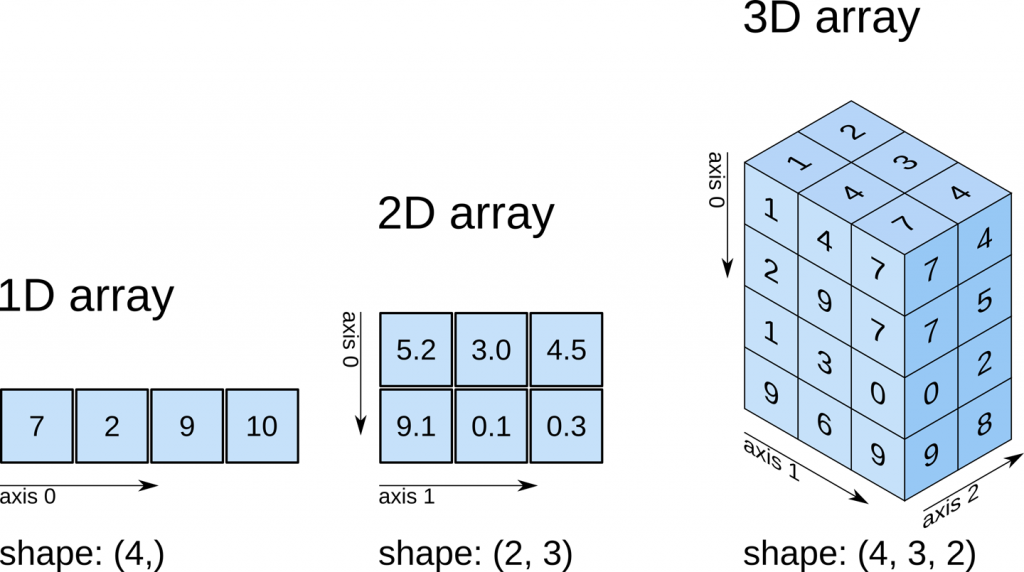

<font size="3"> Dense data operations and algorithms that don’t support sparse matrices directly often require converting the sparse `.X` matrix to a `NumPy` array.

<font size="3"> Convert sparse to dense matrix:

In [ ]:
import scipy.sparse as sp

dense_array = adata.X.toarray() if sp.issparse(adata.X) else adata.X
dense_array

<font size="3"> Convert AnnData count matrix to pandas dataframe:

In [ ]:
adata_df = adata.to_df()
adata_df

### Access 10X Genomics Visium data with <code>sc.datasets.visium_sge</code>

In [ ]:
adata = sc.datasets.visium_sge(sample_id="V1_Mouse_Brain_Sagittal_Posterior")
adata.var_names_make_unique()
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)

In [ ]:
adata

<font size="3"> Here images are stored in: <code>adata.uns['spatial']['V1_Mouse_Brain_Sagittal_Posterior']['images']</code>

In [ ]:
adata.uns['spatial']['V1_Mouse_Brain_Sagittal_Posterior']['images'].keys()

In [ ]:
adata.uns['spatial']['V1_Mouse_Brain_Sagittal_Posterior']['images']['hires'][0].shape

<font size="3"> Given that the image is available, we can overlay spot‑level metadata on top of it to visualize spatial patterns.

In [ ]:
plt.rcParams["figure.figsize"] = (8, 8)
sc.pl.spatial(adata, img_key="hires", color=["total_counts", "n_genes_by_counts"])

<font size="3">For detailed instructions on how to add tissue images to an `AnnData` object using Squidpy, see the tutorial here: [Import spatial data in AnnData & Squidpy](https://squidpy.readthedocs.io/en/stable/notebooks/tutorials/tutorial_read_spatial.html) 
</font>


# Introduction to `SpatialData` objects

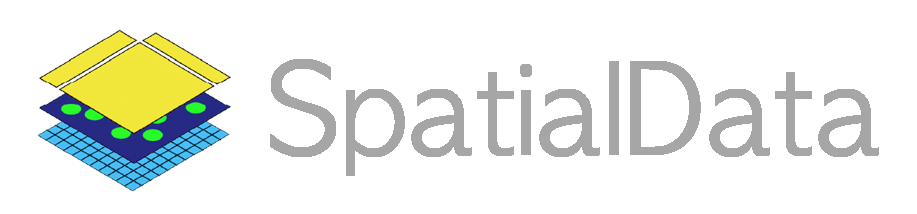

## Reading common raw data formats

<font size="3"> The `spatialdata-io` library allows for reading common raw data formats.
Here we show an example where 3 very different technologies from 10x Genomics are read into a general data structure, given by the [`SpatialData` class](https://spatialdata.scverse.org/en/latest/generated/spatialdata.SpatialData.html#spatialdata.SpatialData).  These are the elements that can be contained inside of a `SpatialData` object:

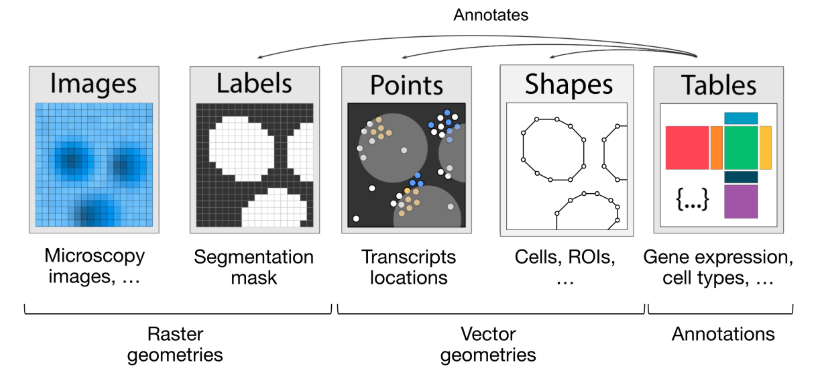

#### SpatialData Data Types

| **Data Type** | **Recommended Object Type** | **Description** |
|----------------|------------------------------|-----------------|
| **Images** | `xarray.DataArray` or `xarray.DataTree` | For single-scale or multi-scale images |
| **Labels** | `xarray.DataArray` or `xarray.DataTree` | Contain integer codes for different labels |
| **Points** | `dask.DataFrame` | Lazy version of `pandas.DataFrame`, used for point coordinates |
| **Shapes** | `geopandas.GeoDataFrame` | Store geometric objects such as polygons |
| **Tables** | `anndata.AnnData` | Used for tabular data with annotations |


<font size="3"> Before any discussion on file structure, let's see how we can download any dataset of interest from 10x (this can be used as a recipe for loading any similar dataset:

In [ ]:
import spatialdata as sd
import spatialdata_plot as sdp
from spatialdata_io import visium, visium_hd, xenium
import matplotlib.pyplot as plt

<font size="3"> This is a way to download any dataset you like from 10X

In [ ]:
#!wget -O /cloud/project/data/visium_hd/Visium_HD_Mouse_Small_Intestine_feature_slice.h5 https://cf.10xgenomics.com/samples/spatial-exp/3.0.0/Visium_HD_Mouse_Small_Intestine/Visium_HD_Mouse_Small_Intestine_feature_slice.h5
#!wget -O /cloud/project/data/visium_hd/Visium_HD_Mouse_Small_Intestine_molecule_info.h5 https://cf.10xgenomics.com/samples/spatial-exp/3.0.0/Visium_HD_Mouse_Small_Intestine/Visium_HD_Mouse_Small_Intestine_molecule_info.h5
#!wget -O /cloud/project/data/visium_hd/Visium_HD_Mouse_Small_Intestine_spatial.tar.gz https://cf.10xgenomics.com/samples/spatial-exp/3.0.0/Visium_HD_Mouse_Small_Intestine/Visium_HD_Mouse_Small_Intestine_spatial.tar.gz
#!wget -O /cloud/project/data/visium_hd/Visium_HD_Mouse_Small_Intestine_binned_outputs.tar.gz https://cf.10xgenomics.com/samples/spatial-exp/3.0.0/Visium_HD_Mouse_Small_Intestine/Visium_HD_Mouse_Small_Intestine_binned_outputs.tar.gz

In [ ]:
#!tar -xvzf /cloud/project/data/visium_hd/Visium_HD_Mouse_Small_Intestine_binned_outputs.tar.gz -C /cloud/project/data/visium_hd/

In [ ]:
sdata_visium_hd = visium_hd("/cloud/project/data/visium_hd")

In [ ]:
sdata_visium_hd

<font size="3"> Similarly, to the regular Visium data, we can read and inspect the individual modalities contained in the data. We can see that the Visium HD data contains a lot more elements in the Shapes slot (351817 vs 5756) due to the increased precision.

<font size="3"> We are making unique all tables for all resolutions

In [ ]:
for table_name, adata in sdata_visium_hd.tables.items():
    print(f"Processing table: {table_name}")
    adata.var_names_make_unique()
    
    
for table_name, adata in sdata_visium_hd.tables.items():
    duplicates = adata.var.index[adata.var.index.duplicated()]
    if duplicates.empty:
        print(f"All variable names are unique in {table_name}.")
    else:
        print(f"Duplicate variable names still exist in {table_name}: {duplicates}")

<font size="3"> `SpatialData Tables` is simply an AnnData object

In [ ]:
adata = sdata_visium_hd["square_016um"]
adata

<font size="3"> `SpatialData Images`
    
<font size="3"> Images can have multiple scales, which are stored in a pyramid for downsampled representations useful for more efficient visualization and analysis. 

In [ ]:
image_h = sdata_visium_hd["Visium_HD_Mouse_Small_Intestine_hires_image"]
image_h

In [ ]:
image_l = sdata_visium_hd["Visium_HD_Mouse_Small_Intestine_lowres_image"]
image_l

In [ ]:
sdata_visium_hd.pl.render_images().pl.show("Visium_HD_Mouse_Small_Intestine_downscaled_hires")

In [ ]:
print(sdata_visium_hd.coordinate_systems)

### Geopandas

<figure>
  <img src="https://geopandas.org/en/stable/_images/dataframe.svg" alt="GeoPandas spatial data frame">
  <figcaption>From <a href="https://geopandas.org/en/stable/getting_started/introduction.html" target="_blank">
      Introduction to GeoPandas
</figure>

<font size="3"> A GeoDataFrame is an object that inherits from a pandas.DataFrame, and as such it supports the APIs that pandas provides, but also new powerful APIs for geometric manipulation.

<font size="3"> The core data structure in GeoPandas is the geopandas.GeoDataFrame, that can store geometry columns and perform spatial operations. The geopandas.GeoSeries handles the geometries. Therefore, your GeoDataFrame is a combination of pandas.Series, with traditional data (numerical, boolean, text etc.), and geopandas.GeoSeries, with geometries (points, polygons etc.). 

<font size="3"> The geometry column is what contains the spatial information.

<font size="3"> In SpatialData, only dataframes where all the geometries are polygons/multipolygons are supported, either where all the geometries are shapely.Point and a column called radius is present. One can add new regular columns to the dataframe.

In [ ]:
sdata_visium_hd['Visium_HD_Mouse_Small_Intestine_square_016um']

In [ ]:
sdata_visium_hd.pl.render_shapes("Visium_HD_Mouse_Small_Intestine_square_016um").pl.show()

Read more: https://spatialdata.scverse.org/en/latest/tutorials/notebooks/notebooks/examples/models1.html and https://geopandas.org/en/stable/getting_started/introduction.html